# 270. What `--scaled` costs on short Swiss-Prot features

`kmerseek index --scaled s` keeps a k-mer when its hash is below $\text{max\_hash}/s$, the
sourmash rule. Query and target use the same hash, so a k-mer they share is kept on both
sides or dropped on both. Each k-mer is kept with probability $1/s$.

**Prediction.** A truth feature of length $F$ residues holds $n = F - k + 1$ k-mers of size
$k$. If each is kept independently with probability $1/s$,

$$\Pr(\text{at least one seed is kept}) = 1 - \left(1 - \tfrac{1}{s}\right)^{F - k + 1}.$$

For $k = 19$ and $F = 25$, $n = 7$: 0.79 at $s = 5$ and 0.52 at $s = 10$. Short features
hold the fewest k-mers, so they lose seeds first. Everything below is split by feature
length: under 30, 30-59, 60-119 and 120 or more residues.

The table under this cell gives the prediction at the k of each arm, for $F$ = 25, 40, 60
and 100 and $s$ = 1, 2, 5 and 10.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

sys.path.insert(0, str(Path.cwd()))
import scaled_270_utils as u

pl.Config.set_tbl_rows(200)
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_width_chars(200)
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight", "font.size": 9.5})
FIG = Path("../figures")
TAB = Path("../tables")

pred = pl.DataFrame(
    [
        {"alphabet": a, "k": k, "F": F, **{f"s={s}": float(u.predicted_reach(F - k + 1, s)) for s in u.SCALED}}
        for a, k, _ in u.ARMS
        for F in (25, 40, 60, 100)
    ]
).with_columns(pl.selectors.starts_with("s=").round(3))
print("Pr(at least one of F - k + 1 k-mers kept), by arm, feature length F and scaled s")
print(pred)
pred.write_csv(TAB / "270_predicted_seed_survival.csv")

Pr(at least one of F - k + 1 k-mers kept), by arm, feature length F and scaled s
shape: (32, 7)
┌──────────────────────────┬─────┬─────┬─────┬───────┬───────┬───────┐
│ alphabet                 ┆ k   ┆ F   ┆ s=1 ┆ s=2   ┆ s=5   ┆ s=10  │
│ ---                      ┆ --- ┆ --- ┆ --- ┆ ---   ┆ ---   ┆ ---   │
│ str                      ┆ i64 ┆ i64 ┆ f64 ┆ f64   ┆ f64   ┆ f64   │
╞══════════════════════════╪═════╪═════╪═════╪═══════╪═══════╪═══════╡
│ hp_lehninger_c_nonpolar2 ┆ 18  ┆ 25  ┆ 1.0 ┆ 0.996 ┆ 0.832 ┆ 0.57  │
│ hp_lehninger_c_nonpolar2 ┆ 18  ┆ 40  ┆ 1.0 ┆ 1.0   ┆ 0.994 ┆ 0.911 │
│ hp_lehninger_c_nonpolar2 ┆ 18  ┆ 60  ┆ 1.0 ┆ 1.0   ┆ 1.0   ┆ 0.989 │
│ hp_lehninger_c_nonpolar2 ┆ 18  ┆ 100 ┆ 1.0 ┆ 1.0   ┆ 1.0   ┆ 1.0   │
│ hp_thomas_dill2          ┆ 19  ┆ 25  ┆ 1.0 ┆ 0.992 ┆ 0.79  ┆ 0.522 │
│ hp_thomas_dill2          ┆ 19  ┆ 40  ┆ 1.0 ┆ 1.0   ┆ 0.993 ┆ 0.902 │
│ hp_thomas_dill2          ┆ 19  ┆ 60  ┆ 1.0 ┆ 1.0   ┆ 1.0   ┆ 0.988 │
│ hp_thomas_dill2          ┆ 19  ┆ 100 ┆ 1.0 ┆ 1.0  

## Result

No scaled value above 1 keeps reach_landed for features under 60 residues within 5
percentage points of scaled 1, for any of the six arms that could be scored, whether all
target proteins count or only those sharing a Pfam family with the query. At scaled 2 the
smallest drop in the worse of the two short bins is 8.8 points (hp_kyte_doolittle2, all
pairs) and 8.5 points (hp_thomas_dill2, Pfam-family pairs). So no memory or time is saved
at a qualifying value. gbmr4 and mmseqs12 could not be scored on extended calls: their
indexes had no E-value fit on these small targets (section 2).

Seeds are lost as the sampling arithmetic predicts once the prediction counts the k-mers
in the exact runs that matched, not the k-mers in the feature: median difference 0.023,
against 0.263 for the formula at the feature's length. Extension does not read the
subsample: 99.91% to 99.99% of extended calls at scaled 2, 5 and 10 are identical to a
call at scaled 1. The boundary error still rises with scaled, because fewer calls are left
to choose the best one from.

These are mini runs: 200 queries, 298 yeast and 172 *E. coli* proteins, tasks of seconds.
Peak memory is not measured at this size (section 7).

## 1. What the code does at scaled above 1

Read once in kmerseek 0aed5ca, the commit inside the image these runs used
(`docker.io/olgabot/kmerseek:0.4.0-rc5`). Line numbers are in `src/rust/search.rs` at that
commit unless another file is named.

- **Seeds.** Above scaled 1, each shared kept k-mer is a seed, and `find_sampled_regions`
  (line 2052) walks its diagonal outward over the stored sequences while the residues agree
  (`exact_run_around`, line 1995). So one kept k-mer anywhere in an exact run of agreeing
  residues recovers the whole run, including the k-mers the sample dropped. At scaled 1 the
  run is read off consecutive shared k-mers instead. The two differ only where a window was
  never in the sketch (a low-complexity window under the mask): that splits a run at
  scaled 1 and not above it.
- **Extension** (`--extend-mismatch-penalty`, the give-up margin walk; BLAST calls it
  X-drop). `extend_regions` walks outward from each seed over the full stored class
  sequence of query and target (`get_class_sequence`, `src/rust/sketch.rs` line 374, which
  falls back to the raw sequence for protein20), not over kept k-mers. Extension does not
  read the subsample.
- **region_mean_idf** (line 1579) is `region_tfidf / region_n_shared_kmers`. The numerator
  sums $\ln(N / \text{df})$ over the query's kept k-mers that fit inside the region
  (`build_idf_prefix`, line 1215; `region_expectation`, line 776). The denominator counts
  the kept k-mers shared with the target inside the region. df, the number of targets
  holding a k-mer, does not change with scaled: a kept k-mer is kept in every target. So
  the IDF of each k-mer is the same at every scaled, and region_mean_idf becomes a ratio of
  two sums over a subsample. Its expected value stays close to the scaled-1 value; its
  spread grows.
- **Karlin-Altschul lambda and K.** lambda for a pair comes from the class composition of
  the full query and target class sequences (line 1585). K and the database scale factor
  are fitted at index time on regions that calibration queries find in this index
  (`run_calibration`, line 916). Those regions are seeded by kept k-mers, and the E-value's
  database size `n` is `db_n_kmers`, the number of kept k-mers (line 1595). So lambda is
  read from the encoded sequences; K is fitted on the subsampled index and absorbs the
  scaled factor. Not changed here.

## 2. The runs

`make run-mini-scaled-270` on branch `olgabot/scaled-sweep-270` (Sherlock), three runs on
the mini set: 200 human queries, 298 yeast and 172 *E. coli* target proteins.

| run | extension | queries |
|---|---|---|
| exact | off | the 200 human proteins |
| extend | on, each alphabet's own mismatch penalty | the 200 human proteins |
| decoy | on | one dipeptide-shuffled copy of each query (same residue pairs, no homolog) |

Arms: the eight alphabets notebook 244 chose for a Swiss-Prot feature type, each at the k
it chose, low-complexity mask on, at scaled 1, 2, 5 and 10. Filters are open: a pair needs
one shared k-mer and no p-value cut is applied.

Truth: the run's Swiss-Prot table (`truth_swissprot/`, the feature key of notebook 231).
An instance is one human range feature (not a 1-2 residue point feature) on a query,
counted once per target species. A region matches an instance when its query interval
overlaps the instance by at least one residue and its target interval overlaps a
Swiss-Prot feature of the same type on that target protein. On the target side a point
feature (1-2 residues, such as BINDING or SITE) counts too; leaving target points out
changes 1 to 5 instances per arm in the under-30 bin and no share by more than 0.003.

- **reach_seed**: share of instances matched by a region of the exact run, that is, an
  exact run of agreeing residues holding at least one kept k-mer.
- **reach_landed**: share of instances matched by an extended call with at least half of
  its length inside the instance (overlap / call length $\ge$ 0.5).
- **Boundary error**: for each landed instance, the landed call with the highest IoU (the
  overlap between call and instance divided by their union); |call start - instance start|
  and |call end - instance end| in residues.

In [2]:
inst = u.load_instances("extend")
tf = u.load_target_features("extend")
reg = {r: u.load_regions(r) for r in ("exact", "extend", "decoy")}
for r, d in reg.items():
    print(f"{r}: {d.height:_} regions; arms x scaled x species present: "
          f"{d.select('alphabet', 'scaled', 'species').unique().height} of "
          f"{len(u.ARMS) * len(u.SCALED) * len(u.SPECIES)}")
print()
print(f"human range instances: {inst.height // len(u.SPECIES):_} on "
      f"{inst['query_acc'].n_unique()} queries, x {len(u.SPECIES)} species = {inst.height:_}")
print(inst.group_by("length_bin").agg(n=pl.len(), median_F=pl.col("feature_length").median())
      .sort(pl.col("length_bin").replace_strict({b: i for i, b in enumerate(u.LENGTH_BINS)})))
# The truth tables must be the same in every run.
for r in ("exact", "decoy"):
    other = u.load_instances(r)
    assert other.sort(other.columns).equals(inst.sort(inst.columns)), r
print("truth instances identical in exact, extend and decoy runs")

exact: 4_367_838 regions; arms x scaled x species present: 64 of 64
extend: 4_355_812 regions; arms x scaled x species present: 64 of 64
decoy: 4_227_643 regions; arms x scaled x species present: 64 of 64

human range instances: 5_260 on 163 queries, x 2 species = 10_520
shape: (4, 3)
┌────────────┬──────┬──────────┐
│ length_bin ┆ n    ┆ median_F │
│ ---        ┆ ---  ┆ ---      │
│ str        ┆ u32  ┆ f64      │
╞════════════╪══════╪══════════╡
│ < 30       ┆ 2894 ┆ 23.0     │
│ 30-59      ┆ 3846 ┆ 40.0     │
│ 60-119     ┆ 3210 ┆ 94.0     │
│ >= 120     ┆ 570  ┆ 186.0    │
└────────────┴──────┴──────────┘
truth instances identical in exact, extend and decoy runs


5_260 human range features on 163 of the 200 queries, counted once per species: 10_520
instances. 2_894 are under 30 residues (median 23) and 3_846 are 30-59 (median 40).

### Which tables were extended

When an index has no Karlin-Altschul fit, the pipeline's search step writes exact regions
under the extended run's name (its log says "searching again without extension"). A fit
needs at least 4 score bins of 30 regions above the peak of the score histogram, and the
mini targets (298 and 172 proteins) do not always give that. The table below finds those
cases from the rows themselves: an extended table has finite E-values and regions with
mismatches. Everything that depends on extension (reach_landed, boundary error, decoy
calls, cost of the extended arm) uses only the (alphabet, species) pairs extended at all
four scaled values in both the real and the decoy run.

In [3]:
status = {r: u.extension_status(reg[r]) for r in reg}
assert status["exact"].filter("extended").height == 0, "the exact run has extended tables"
for r in ("extend", "decoy"):
    t = status[r].filter(~pl.col("extended")).sort("alphabet", "species", "scaled")
    print(f"{r}: {t.height} of {status[r].height} tables not extended")
    print(t.select("alphabet", "species", "scaled", "n_regions"))
EXT_OK = u.extended_at_every_scaled(status["extend"], status["decoy"])
print("(alphabet, species) pairs extended at scaled 1, 2, 5 and 10 in both runs:")
print(EXT_OK)
EXT_ARMS = [a for a in u.ARM_ORDER if a in set(EXT_OK["alphabet"])]
_sp = EXT_OK.group_by("alphabet").agg(pl.col("species").sort())
SPN = {a: ", ".join(sp) + " only" for a, sp in _sp.iter_rows() if len(sp) < len(u.SPECIES)}

extend: 17 of 64 tables not extended
shape: (17, 4)
┌──────────────────────┬─────────┬────────┬───────────┐
│ alphabet             ┆ species ┆ scaled ┆ n_regions │
│ ---                  ┆ ---     ┆ ---    ┆ ---       │
│ str                  ┆ str     ┆ i64    ┆ u32       │
╞══════════════════════╪═════════╪════════╪═══════════╡
│ gbmr4                ┆ ecoli   ┆ 1      ┆ 10012     │
│ gbmr4                ┆ ecoli   ┆ 2      ┆ 6207      │
│ gbmr4                ┆ ecoli   ┆ 5      ┆ 2941      │
│ gbmr4                ┆ ecoli   ┆ 10     ┆ 1549      │
│ gbmr4                ┆ yeast   ┆ 1      ┆ 50031     │
│ gbmr4                ┆ yeast   ┆ 2      ┆ 32388     │
│ gbmr4                ┆ yeast   ┆ 5      ┆ 14194     │
│ gbmr4                ┆ yeast   ┆ 10     ┆ 8104      │
│ hp_thomas_dill_no_c2 ┆ ecoli   ┆ 10     ┆ 8558      │
│ mmseqs12             ┆ ecoli   ┆ 2      ┆ 3296      │
│ mmseqs12             ┆ ecoli   ┆ 5      ┆ 1416      │
│ mmseqs12             ┆ ecoli   ┆ 10     ┆ 692     

17 of the 64 tables in each of the extend and decoy runs were not extended: gbmr4 at every
scaled in both species, mmseqs12 at scaled 2, 5 and 10 in both, protein20 *E. coli* at
scaled 5 and 10, and hp_thomas_dill_no_c2 *E. coli* at scaled 10. Six arms remain for the
extended metrics: four in both species, and hp_thomas_dill_no_c2 and protein20 in yeast
only. Each index log gives the reason: the fit's regions fell into fewer than 4 score bins
of 30 regions above the peak. Whether the same arms fit on full proteomes is not checked
here.

## 3. Seeds kept: measured against predicted

The formula assumes every one of the $F - k + 1$ k-mers in the feature is shared with the
target. Most instances have no homolog in yeast or *E. coli*, so the measured share at
scaled 1 is far below 1. The figure therefore shows, for the instances that had a seed at
scaled 1, the share that still has one at scaled $s$. On that set the formula is 1 at
scaled 1 too, and the two curves can be compared.

In [4]:
ex = u.match_instances(u.typed_regions(reg["exact"], tf), inst)
seed = u.reached(ex, inst, landed=False)
base = seed.filter(pl.col("scaled") == 1).filter("reached").select(["alphabet"] + u.INSTANCE_KEY)
seed_c = seed.join(base, on=["alphabet"] + u.INSTANCE_KEY, how="inner")

nk = u.seed_kmers_at_scaled1(ex)
seed_c = seed_c.join(nk.drop("k"), on=["alphabet"] + u.INSTANCE_KEY, how="left")
assert seed_c["n_kmers"].null_count() == 0
seed_c = seed_c.with_columns(
    pred_run=pl.struct("n_kmers", "scaled").map_elements(
        lambda r: float(u.predicted_reach(r["n_kmers"], r["scaled"])), return_dtype=pl.Float64),
    pred_F=pl.struct("feature_length", "k", "scaled").map_elements(
        lambda r: float(u.predicted_reach(max(r["feature_length"] - r["k"] + 1, 0), r["scaled"])),
        return_dtype=pl.Float64),
)
S1 = (
    seed_c.group_by(["alphabet", "k", "scaled", "length_bin"])
    .agg(
        n_at_scaled1=pl.len(),
        n_kept=pl.col("reached").sum(),
        measured=pl.col("reached").mean(),
        pred_runs=pl.col("pred_run").mean(),
        pred_feature=pl.col("pred_F").mean(),
        median_F=pl.col("feature_length").median(),
    )
    .with_columns(pred_formula_medianF=pl.struct("median_F", "k", "scaled").map_elements(
        lambda r: float(u.predicted_reach(max(r["median_F"] - r["k"] + 1, 0), r["scaled"])),
        return_dtype=pl.Float64))
    .sort("alphabet", "length_bin", "scaled")
)
print("Instances with a seed at scaled 1: share still seeded at scaled s.")
print("pred_formula_medianF: the formula at the bin's median F.  pred_feature: the formula per")
print("instance at its own F, averaged.  pred_runs: 1 - (1 - 1/s)^n with n the k-mers in the")
print("exact runs that matched the instance at scaled 1, averaged.")
print(S1.with_columns(pl.selectors.float().round(3)))
S1.write_csv(TAB / "270_reach_seed_vs_predicted.csv")
print()
print("k-mers per instance at scaled 1: in its feature (F - k + 1) and in the exact runs that matched it")
print(seed_c.filter(pl.col("scaled") == 1).group_by("alphabet", "length_bin").agg(
    n=pl.len(), median_kmers_in_feature=(pl.col("feature_length") - pl.col("k") + 1).median(),
    median_kmers_in_runs=pl.col("n_kmers").median(), median_runs=pl.col("n_runs").median(),
).sort("alphabet", "length_bin"))

Instances with a seed at scaled 1: share still seeded at scaled s.
pred_formula_medianF: the formula at the bin's median F.  pred_feature: the formula per
instance at its own F, averaged.  pred_runs: 1 - (1 - 1/s)^n with n the k-mers in the
exact runs that matched the instance at scaled 1, averaged.
shape: (128, 11)
┌──────────────────────────┬─────┬────────┬────────────┬──────────────┬────────┬──────────┬───────────┬──────────────┬──────────┬──────────────────────┐
│ alphabet                 ┆ k   ┆ scaled ┆ length_bin ┆ n_at_scaled1 ┆ n_kept ┆ measured ┆ pred_runs ┆ pred_feature ┆ median_F ┆ pred_formula_medianF │
│ ---                      ┆ --- ┆ ---    ┆ ---        ┆ ---          ┆ ---    ┆ ---      ┆ ---       ┆ ---          ┆ ---      ┆ ---                  │
│ str                      ┆ i32 ┆ i64    ┆ str        ┆ u32          ┆ u32    ┆ f64      ┆ f64       ┆ f64          ┆ f64      ┆ f64                  │
╞══════════════════════════╪═════╪════════╪════════════╪══════════════

In [5]:
# Absolute reach_seed and reach_landed, all instances in the denominator.
xt = u.match_instances(u.typed_regions(reg["extend"], tf), inst)
land = u.reached(xt, inst, landed=True)
# Rows only for (alphabet, species) pairs extended at every scaled.
land = land.join(EXT_OK, on=["alphabet", "species"], how="semi")
def absolute(d, name):
    return (d.group_by(["alphabet", "k", "scaled", "length_bin"])
            .agg(n_instances=pl.len(), **{f"n_{name}": pl.col("reached").sum()},
                 **{name: pl.col("reached").mean()}))
ABS = absolute(seed.join(EXT_OK, on=["alphabet", "species"], how="semi"), "reach_seed").join(
    absolute(land, "reach_landed").drop("n_instances"), on=["alphabet", "k", "scaled", "length_bin"])
print("(seed and landed both over the extended (alphabet, species) pairs only)")
ABS = ABS.sort("alphabet", "length_bin", "scaled")
print("Share of all instances, by arm, length bin and scaled")
print(ABS.with_columns(pl.selectors.float().round(4)))
ABS.write_csv(TAB / "270_reach_absolute.csv")

(seed and landed both over the extended (alphabet, species) pairs only)
Share of all instances, by arm, length bin and scaled
shape: (96, 9)
┌──────────────────────────┬─────┬────────┬────────────┬─────────────┬──────────────┬────────────┬────────────────┬──────────────┐
│ alphabet                 ┆ k   ┆ scaled ┆ length_bin ┆ n_instances ┆ n_reach_seed ┆ reach_seed ┆ n_reach_landed ┆ reach_landed │
│ ---                      ┆ --- ┆ ---    ┆ ---        ┆ ---         ┆ ---          ┆ ---        ┆ ---            ┆ ---          │
│ str                      ┆ i32 ┆ i64    ┆ str        ┆ u32         ┆ u32          ┆ f64        ┆ u32            ┆ f64          │
╞══════════════════════════╪═════╪════════╪════════════╪═════════════╪══════════════╪════════════╪════════════════╪══════════════╡
│ hp_kyte_doolittle2       ┆ 19  ┆ 1      ┆ 30-59      ┆ 3846        ┆ 2648         ┆ 0.6885     ┆ 2389           ┆ 0.6212       │
│ hp_kyte_doolittle2       ┆ 19  ┆ 2      ┆ 30-59      ┆ 3846        ┆ 24

## Figures

Colour marks the alphabet group: blue for the four 2-letter hydrophobic-polar alphabets,
orange for the three larger reduced alphabets, black for protein20. Marker shape marks the
alphabet within its group. Solid lines with markers are measured; dashed lines are
predicted.

In [6]:
GROUP_COLOR = {"hp": "#2166ac", "reduced": "#d6604d", "protein20": "#111111"}
def group(a):
    return "protein20" if a == "protein20" else ("hp" if a.startswith("hp_") else "reduced")
MARK = {"hp_lehninger_c_nonpolar2": "o", "hp_thomas_dill2": "s", "hp_thomas_dill_no_c2": "^",
        "hp_kyte_doolittle2": "D", "gbmr4": "o", "mmseqs12": "s", "sdm12": "^", "protein20": "o"}
def arm_label(a):
    return f"{a}, k = {u.ARM_K[a]}"
def arm_handles(extra=(), arms=None, species_note=None):
    from matplotlib.lines import Line2D
    arms = u.ARM_ORDER if arms is None else arms
    note = species_note or {}
    h = [Line2D([], [], color=GROUP_COLOR[group(a)], marker=MARK[a],
                label=arm_label(a) + (f" ({note[a]})" if a in note else ""))
         for a in arms]
    return h + list(extra)

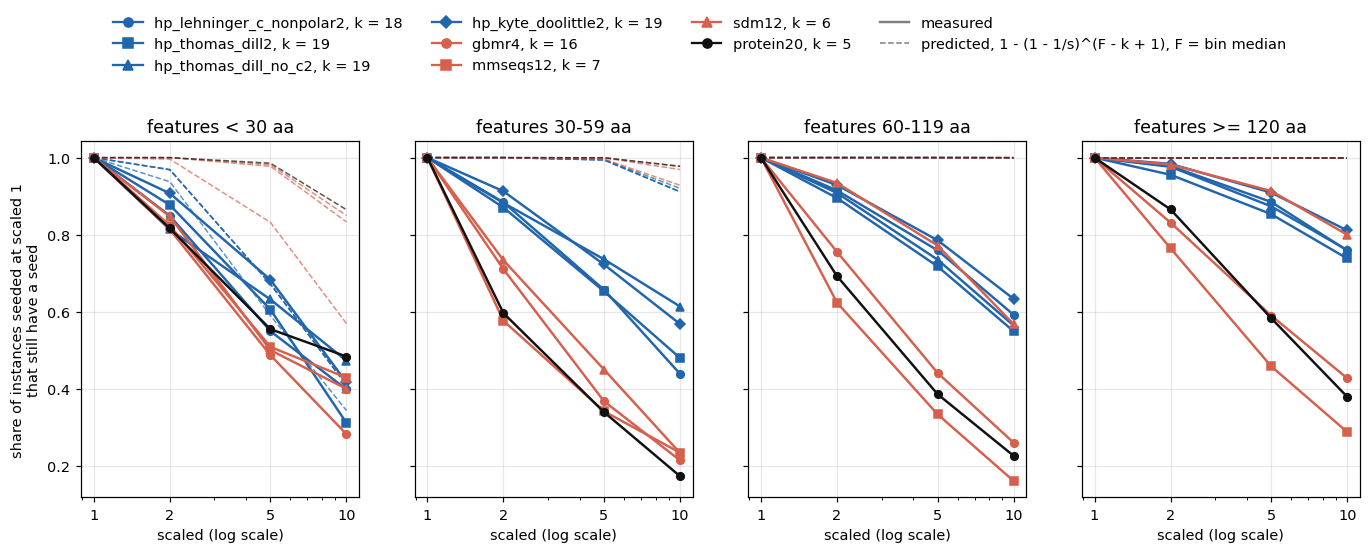

In [7]:
from matplotlib.lines import Line2D
fig, axes = plt.subplots(1, 4, figsize=(15, 4.2), sharey=True)
for ax, b in zip(axes, u.LENGTH_BINS):
    for a in u.ARM_ORDER:
        t = S1.filter((pl.col("alphabet") == a) & (pl.col("length_bin") == b)).sort("scaled")
        if t.height == 0:
            continue
        c = GROUP_COLOR[group(a)]
        ax.plot(t["scaled"], t["pred_formula_medianF"], color=c, lw=1, ls="--", alpha=0.7)
        ax.plot(t["scaled"], t["measured"], color=c, marker=MARK[a], lw=1.6, ms=5)
    ax.set_xscale("log")
    ax.set_xticks(u.SCALED, [str(s) for s in u.SCALED])
    ax.set_title(f"features {b} aa")
    ax.set_xlabel("scaled (log scale)")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("share of instances seeded at scaled 1\nthat still have a seed")
extra = [Line2D([], [], color="grey", lw=1.6, label="measured"),
         Line2D([], [], color="grey", lw=1, ls="--", label="predicted, 1 - (1 - 1/s)^(F - k + 1), F = bin median")]
fig.legend(handles=arm_handles(extra), loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=4, frameon=False)
fig.savefig(FIG / "270_reach_seed_vs_scaled.png")

points: 96; median |measured - pred_runs| = 0.023; median |measured - formula at median F| = 0.263


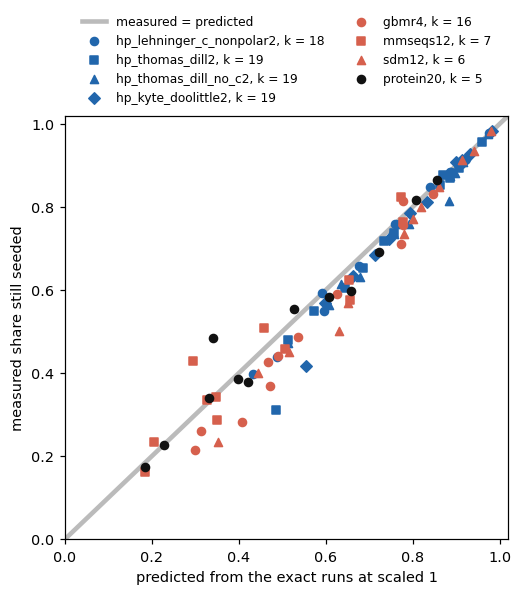

In [8]:
fig, ax = plt.subplots(figsize=(5.2, 5))
lim = (0, 1.02)
ax.plot(lim, lim, color="#bbbbbb", lw=3, zorder=0, label="measured = predicted")
for a in u.ARM_ORDER:
    t = S1.filter((pl.col("alphabet") == a) & (pl.col("scaled") > 1))
    ax.scatter(t["pred_runs"], t["measured"], color=GROUP_COLOR[group(a)], marker=MARK[a], s=28,
               label=arm_label(a))
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("predicted from the exact runs at scaled 1")
ax.set_ylabel("measured share still seeded")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False, fontsize=8)
fig.savefig(FIG / "270_reach_seed_measured_vs_run_prediction.png")
t = S1.filter(pl.col("scaled") > 1)
print(f"points: {t.height}; median |measured - pred_runs| = "
      f"{(t['measured'] - t['pred_runs']).abs().median():.3f}; "
      f"median |measured - formula at median F| = {(t['measured'] - t['pred_formula_medianF']).abs().median():.3f}")

### Figure 1 and the prediction

On the instances seeded at scaled 1, the formula at the bin's median length predicts more
survivors than are measured, by a median of 0.263 over the 96 (arm, scaled, length bin)
points. hp_kyte_doolittle2 on 30-59 residue features at scaled 5: measured 0.723, formula
0.994.

The formula assumes all $F - k + 1$ k-mers of the feature are shared with the target. They
are not. For hp_kyte_doolittle2 on 30-59 residue features, the feature holds a median of 23
k-mers and the exact runs that matched it hold 9. For protein20 at k = 5 the numbers are 36
and 1. A feature is usually reached through one or a few short exact runs, many of them
chance matches (the decoy line in figure 2 shows how many).

Counting the k-mers in those runs instead, $1 - (1 - 1/s)^{n}$ with $n$ summed over the
runs, matches the measured share to a median of 0.023 (scatter above). The largest gaps are
on features under 30 residues at scaled 10, where the prediction is higher: 0.554 against
0.417 measured for hp_kyte_doolittle2. Two things the independence assumption ignores
could explain it. A k-mer that occurs twice is kept or dropped in both places at once (not
measured here). And runs differ between the two code paths: with the mask on, a
low-complexity window splits a run at scaled 1, while the residue walk above scaled 1 runs
through it. An independent recount found 1.96% of exact regions at scaled 2, 5 and 10
(45_685 of 2_328_162) longer than the matching scaled-1 region on the same diagonal, mostly
in repeat-rich queries (filaggrin, NBPF, collagens), and 29 hp_kyte_doolittle2 instances
matched above scaled 1 but not at scaled 1. Those 29 are outside the denominator here.

Instances seeded at scaled 1: share with a landed extended call at scaled s;
landed_decoy: the same share for the decoy shuffled from the same query (chance level)
shape: (96, 10)
┌──────────────────────────┬─────┬────────┬────────────┬──────┬──────────┬────────┬──────────┬──────────────────────┬──────────────┐
│ alphabet                 ┆ k   ┆ scaled ┆ length_bin ┆ n    ┆ n_landed ┆ landed ┆ measured ┆ pred_formula_medianF ┆ landed_decoy │
│ ---                      ┆ --- ┆ ---    ┆ ---        ┆ ---  ┆ ---      ┆ ---    ┆ ---      ┆ ---                  ┆ ---          │
│ str                      ┆ i32 ┆ i64    ┆ str        ┆ u32  ┆ u32      ┆ f64    ┆ f64      ┆ f64                  ┆ f64          │
╞══════════════════════════╪═════╪════════╪════════════╪══════╪══════════╪════════╪══════════╪══════════════════════╪══════════════╡
│ hp_kyte_doolittle2       ┆ 19  ┆ 1      ┆ 30-59      ┆ 2648 ┆ 2357     ┆ 0.89   ┆ 1.0      ┆ 1.0                  ┆ 0.769        │
│ hp_kyte_doolittle2  

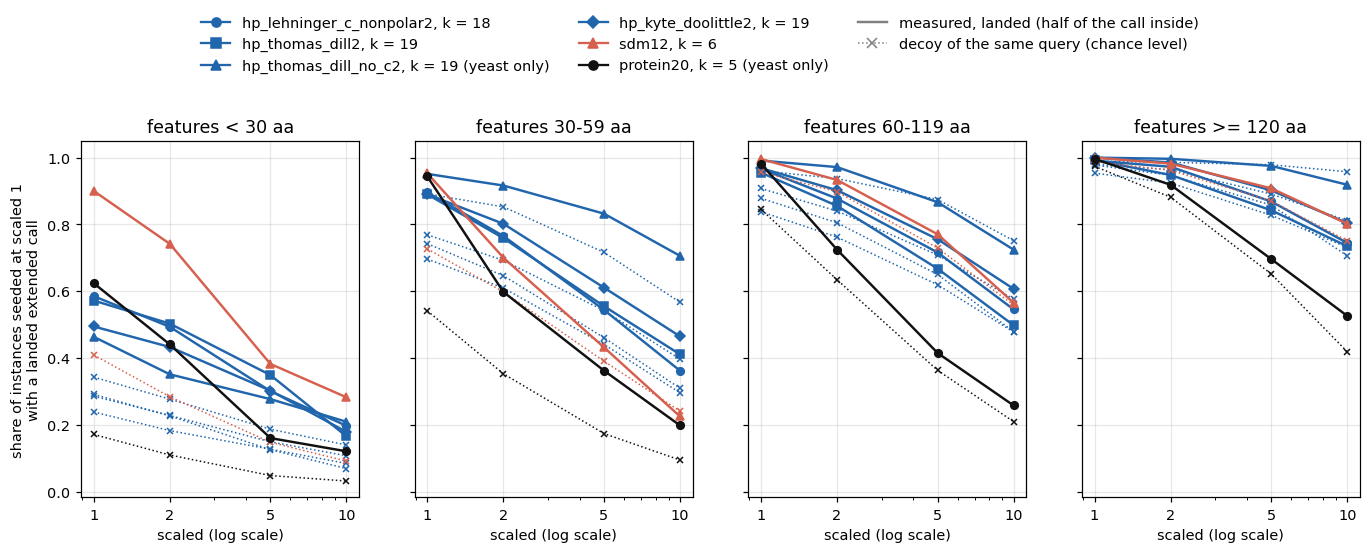

In [9]:
# Figure 2: reach_landed on the same set (instances seeded at scaled 1), so the vertical gap to
# figure 1 is what extension changes.
land_c = land.join(base, on=["alphabet"] + u.INSTANCE_KEY, how="inner")
L1 = (land_c.group_by(["alphabet", "k", "scaled", "length_bin"])
      .agg(n=pl.len(), n_landed=pl.col("reached").sum(), landed=pl.col("reached").mean())
      .join(S1.select("alphabet", "scaled", "length_bin", "measured", "pred_formula_medianF"),
            on=["alphabet", "scaled", "length_bin"])
      .sort("alphabet", "length_bin", "scaled"))
# Chance level: the decoy calls scored against the features of the protein each decoy was
# shuffled from, on the same instances (seeded by the real query at scaled 1).
dec = reg["decoy"].with_columns(pl.col("query_acc").str.strip_prefix("DECOY_"))
xd = u.match_instances(u.typed_regions(dec, tf), inst)
land_d = u.reached(xd, inst, landed=True).join(EXT_OK, on=["alphabet", "species"], how="semi")
L1d = (land_d.join(base, on=["alphabet"] + u.INSTANCE_KEY, how="inner")
       .group_by(["alphabet", "scaled", "length_bin"]).agg(landed_decoy=pl.col("reached").mean()))
L1 = L1.join(L1d, on=["alphabet", "scaled", "length_bin"], how="left")
print("Instances seeded at scaled 1: share with a landed extended call at scaled s;")
print("landed_decoy: the same share for the decoy shuffled from the same query (chance level)")
print(L1.with_columns(pl.selectors.float().round(3)))
L1.write_csv(TAB / "270_reach_landed.csv")

fig, axes = plt.subplots(1, 4, figsize=(15, 4.2), sharey=True)
for ax, b in zip(axes, u.LENGTH_BINS):
    for a in u.ARM_ORDER:
        t = L1.filter((pl.col("alphabet") == a) & (pl.col("length_bin") == b)).sort("scaled")
        if t.height == 0:
            continue
        c = GROUP_COLOR[group(a)]
        ax.plot(t["scaled"], t["landed_decoy"], color=c, lw=1, ls=":", marker="x", ms=4)
        ax.plot(t["scaled"], t["landed"], color=c, marker=MARK[a], lw=1.6, ms=5)
    ax.set_xscale("log"); ax.set_xticks(u.SCALED, [str(s) for s in u.SCALED])
    ax.set_title(f"features {b} aa"); ax.set_xlabel("scaled (log scale)"); ax.grid(alpha=0.3)
axes[0].set_ylabel("share of instances seeded at scaled 1\nwith a landed extended call")
extra = [Line2D([], [], color="grey", lw=1.6, label="measured, landed (half of the call inside)"),
         Line2D([], [], color="grey", lw=1, ls=":", marker="x", label="decoy of the same query (chance level)")]
fig.legend(handles=arm_handles(extra, arms=EXT_ARMS, species_note=SPN), loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=False)
fig.savefig(FIG / "270_reach_landed_vs_scaled.png")

### Figure 2

On the instances seeded at scaled 1, reach_landed at scaled 1 is 0.89 to 0.95 for 30-59
residue features and 0.46 to 0.90 for features under 30. It falls with scaled about as fast
as the seeds do in figure 1: an instance that loses its seed loses its call.

The decoy line is high. With open filters, a decoy shuffled from the same query lands on
0.54 to 0.89 of the 30-59 residue instances at scaled 1 (protein20 0.54,
hp_thomas_dill_no_c2 0.89), against 0.89 to 0.95 for the real query. Most of what lands on all pairs is a chance
match to a same-type feature, and the next section restricts the count to pairs that share
a Pfam family.

### The same, on pairs that share a Pfam family

With the filters open, most matches above are between proteins with no shared ancestry: a
run of 18-19 residues in a 2-letter alphabet, or of 5-7 in a large one, turns up by chance,
and a feature of the same type on the target is common. The decoy line in figure 2 shows
how much. Here the matches are kept only when the human query and the target protein share
at least one Pfam family (the mini set's Pfam tables). There are 662 such pairs in yeast
and 31 in *E. coli*, so these counts are small.

Pfam-homolog pairs only. Instances seeded at scaled 1 on such a pair: share still seeded,
share landed, and share landed by the decoy of the same query
shape: (96, 11)
┌──────────────────────────┬─────┬────────┬────────────┬─────┬──────────┬────────┬──────────┬────────┬────────────────┬──────────────┐
│ alphabet                 ┆ k   ┆ scaled ┆ length_bin ┆ n   ┆ n_seeded ┆ seeded ┆ n_landed ┆ landed ┆ n_landed_decoy ┆ landed_decoy │
│ ---                      ┆ --- ┆ ---    ┆ ---        ┆ --- ┆ ---      ┆ ---    ┆ ---      ┆ ---    ┆ ---            ┆ ---          │
│ str                      ┆ i32 ┆ i64    ┆ str        ┆ u32 ┆ u32      ┆ f64    ┆ u32      ┆ f64    ┆ u32            ┆ f64          │
╞══════════════════════════╪═════╪════════╪════════════╪═════╪══════════╪════════╪══════════╪════════╪════════════════╪══════════════╡
│ hp_kyte_doolittle2       ┆ 19  ┆ 1      ┆ 30-59      ┆ 121 ┆ 121      ┆ 1.0    ┆ 90       ┆ 0.744  ┆ 33             ┆ 0.273        │
│ hp_kyte_doolittle2  

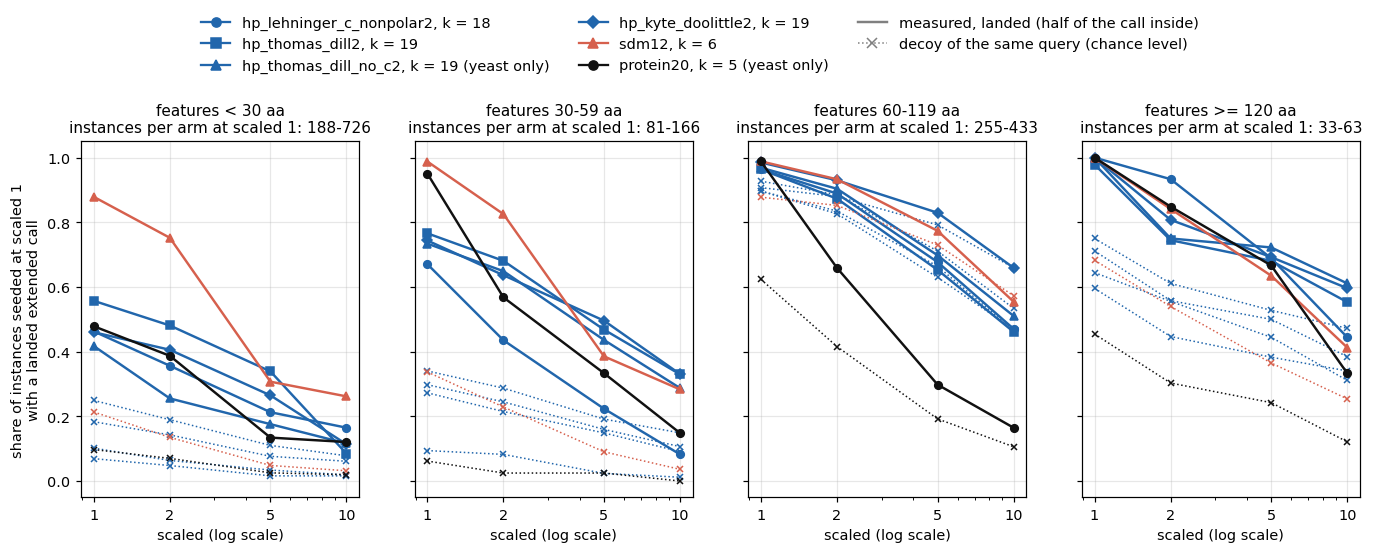

In [10]:
H = u.pfam_homolog_pairs()
def landed_on_pairs(matches, pairs):
    m = matches.join(pairs, on=["species", "query_acc", "target_acc"], how="semi")
    return u.reached(m, inst, landed=True).join(EXT_OK, on=["alphabet", "species"], how="semi")
ex_h = ex.join(H, on=["species", "query_acc", "target_acc"], how="semi")
seed_h = u.reached(ex_h, inst, landed=False)
base_h = seed_h.filter((pl.col("scaled") == 1) & pl.col("reached")).select(["alphabet"] + u.INSTANCE_KEY)
land_h = landed_on_pairs(xt, H)
xd_h = xd  # decoy calls, query accession mapped back to its source protein
land_hd = landed_on_pairs(xd_h, H)
def share(d, base_, name):
    return (d.join(base_, on=["alphabet"] + u.INSTANCE_KEY, how="inner")
            .group_by(["alphabet", "k", "scaled", "length_bin"])
            .agg(n=pl.len(), **{f"n_{name}": pl.col("reached").sum()}, **{name: pl.col("reached").mean()}))
L1h = (share(seed_h.join(EXT_OK, on=["alphabet", "species"], how="semi"), base_h, "seeded")
       .join(share(land_h, base_h, "landed").drop("n"), on=["alphabet", "k", "scaled", "length_bin"], how="left")
       .join(share(land_hd, base_h, "landed_decoy").drop("n"), on=["alphabet", "k", "scaled", "length_bin"], how="left")
       .sort("alphabet", "length_bin", "scaled"))
print("Pfam-homolog pairs only. Instances seeded at scaled 1 on such a pair: share still seeded,")
print("share landed, and share landed by the decoy of the same query")
print(L1h.with_columns(pl.selectors.float().round(3)))
L1h.write_csv(TAB / "270_reach_landed_pfam_pairs.csv")

fig, axes = plt.subplots(1, 4, figsize=(15, 4.2), sharey=True)
for ax, b in zip(axes, u.LENGTH_BINS):
    for a in EXT_ARMS:
        t = L1h.filter((pl.col("alphabet") == a) & (pl.col("length_bin") == b)).sort("scaled")
        if t.height == 0:
            continue
        c = GROUP_COLOR[group(a)]
        ax.plot(t["scaled"], t["landed_decoy"], color=c, lw=1, ls=":", marker="x", ms=4)
        ax.plot(t["scaled"], t["landed"], color=c, marker=MARK[a], lw=1.6, ms=5)
    n1 = L1h.filter((pl.col("length_bin") == b) & (pl.col("scaled") == 1))["n"]
    ax.set_title(f"features {b} aa\ninstances per arm at scaled 1: {n1.min() if n1.len() else 0}-{n1.max() if n1.len() else 0}", fontsize=10)
    ax.set_xscale("log"); ax.set_xticks(u.SCALED, [str(s) for s in u.SCALED])
    ax.set_xlabel("scaled (log scale)"); ax.grid(alpha=0.3)
axes[0].set_ylabel("share of instances seeded at scaled 1\nwith a landed extended call")
extra = [Line2D([], [], color="grey", lw=1.6, label="measured, landed (half of the call inside)"),
         Line2D([], [], color="grey", lw=1, ls=":", marker="x", label="decoy of the same query (chance level)")]
fig.legend(handles=arm_handles(extra, arms=EXT_ARMS, species_note=SPN), loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=False)
fig.savefig(FIG / "270_reach_landed_pfam_pairs_vs_scaled.png")

On Pfam-family pairs the real and decoy lines separate. At scaled 1 on 30-59 residue
features: hp_kyte_doolittle2 0.744 against 0.273 for decoys, hp_thomas_dill2 0.766 against
0.298, protein20 (yeast) 0.951 against 0.062, sdm12 0.988 against 0.337. The counts are
small: 81 to 166 instances per arm in that bin, 188 to 726 under 30 residues. The drops
with scaled are of the same size as on all pairs (table in section 8).

Best landed call per instance: median boundary error (residues) and IoU
shape: (96, 8)
┌──────────────────────────┬─────┬────────┬────────────┬──────────┬──────────────────┬────────────────┬────────────┐
│ alphabet                 ┆ k   ┆ scaled ┆ length_bin ┆ n_landed ┆ median_start_err ┆ median_end_err ┆ median_iou │
│ ---                      ┆ --- ┆ ---    ┆ ---        ┆ ---      ┆ ---              ┆ ---            ┆ ---        │
│ str                      ┆ i32 ┆ i64    ┆ str        ┆ u32      ┆ f64              ┆ f64            ┆ f64        │
╞══════════════════════════╪═════╪════════╪════════════╪══════════╪══════════════════╪════════════════╪════════════╡
│ hp_kyte_doolittle2       ┆ 19  ┆ 1      ┆ 30-59      ┆ 2389     ┆ 7.0              ┆ 6.0            ┆ 0.69       │
│ hp_kyte_doolittle2       ┆ 19  ┆ 2      ┆ 30-59      ┆ 2145     ┆ 7.0              ┆ 7.0            ┆ 0.67       │
│ hp_kyte_doolittle2       ┆ 19  ┆ 5      ┆ 30-59      ┆ 1624     ┆ 8.0              ┆ 8.0    

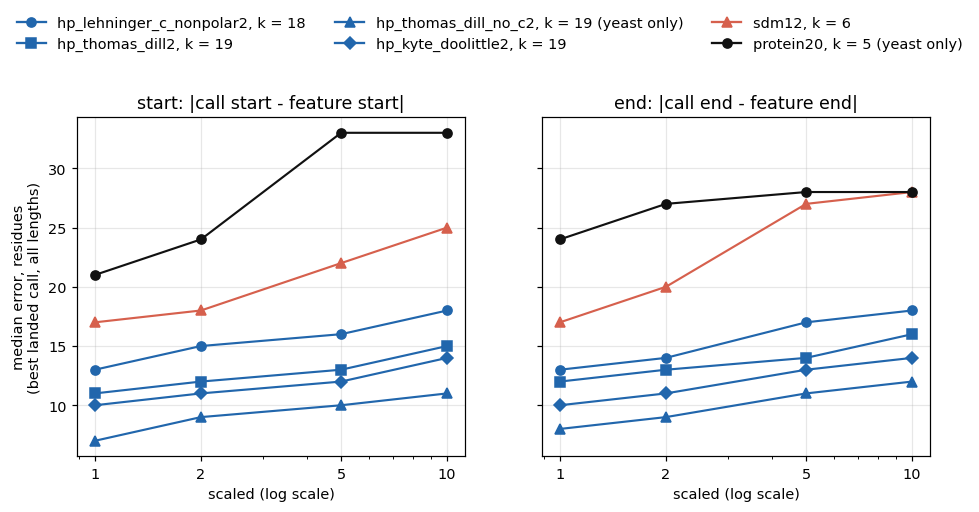

In [11]:
# Figure 3: boundary error of the best landed call, all landed instances.
BE = (land.filter("reached").group_by(["alphabet", "k", "scaled", "length_bin"])
      .agg(n_landed=pl.len(), median_start_err=pl.col("start_err").median(),
           median_end_err=pl.col("end_err").median(), median_iou=pl.col("iou").median())
      .sort("alphabet", "length_bin", "scaled"))
print("Best landed call per instance: median boundary error (residues) and IoU")
print(BE.with_columns(pl.selectors.float().round(2)))
BE.write_csv(TAB / "270_boundary_error.csv")
BE_ALL = (land.filter("reached").group_by(["alphabet", "scaled"])
          .agg(n=pl.len(), start=pl.col("start_err").median(), end=pl.col("end_err").median())
          .sort("alphabet", "scaled"))
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, col, name in zip(axes, ["start", "end"], ["start", "end"]):
    for a in EXT_ARMS:
        t = BE_ALL.filter(pl.col("alphabet") == a).sort("scaled")
        ax.plot(t["scaled"], t[col], color=GROUP_COLOR[group(a)], marker=MARK[a], lw=1.4)
    ax.set_xscale("log"); ax.set_xticks(u.SCALED, [str(s) for s in u.SCALED])
    ax.set_xlabel("scaled (log scale)"); ax.set_title(f"{name}: |call {name} - feature {name}|"); ax.grid(alpha=0.3)
axes[0].set_ylabel("median error, residues\n(best landed call, all lengths)")
fig.legend(handles=arm_handles(arms=EXT_ARMS, species_note=SPN), loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=False)
fig.savefig(FIG / "270_boundary_error_vs_scaled.png")
print(BE_ALL)

### Does extension read the subsample?

If extension walks the full sequences, an extended call at scaled $s$ grows from a seed to
the same end points as it would at scaled 1. Every extended call at scaled above 1 should
then be identical, residue for residue on both proteins, to a call at scaled 1, and the
boundary error can move only because there are fewer calls per instance to choose the best
from.

In [12]:
key = ["species", "alphabet", "query_acc", "target_acc", "qs", "qe", "ts", "te"]
xe = reg["extend"].join(EXT_OK, on=["alphabet", "species"], how="semi")
s1 = xe.filter(pl.col("scaled") == 1).select(key).unique().with_columns(in_s1=pl.lit(True))
SAME = (xe.filter(pl.col("scaled") > 1).select(key + ["scaled"]).unique()
        .join(s1, on=key, how="left").with_columns(pl.col("in_s1").fill_null(False))
        .group_by("alphabet", "scaled")
        .agg(n_calls=pl.len(), n_identical=pl.col("in_s1").sum(), share_identical=pl.col("in_s1").mean())
        .sort("alphabet", "scaled"))
print("Extended calls at scaled > 1 identical (same proteins, same start and end on both) to a call at scaled 1")
print(SAME.with_columns(pl.col("share_identical").round(4)))
SAME.write_csv(TAB / "270_extended_calls_identical_to_scaled1.csv")
# Boundary error on the instances landed at every scaled, with the call chosen at each scaled.
both = (land.filter("reached").group_by(["alphabet"] + u.INSTANCE_KEY).agg(n_s=pl.len())
        .filter(pl.col("n_s") == len(u.SCALED)).select(["alphabet"] + u.INSTANCE_KEY))
BE_FIXED = (land.filter("reached").join(both, on=["alphabet"] + u.INSTANCE_KEY, how="semi")
            .group_by("alphabet", "scaled").agg(n=pl.len(), start=pl.col("start_err").median(),
                                                end=pl.col("end_err").median(), iou=pl.col("iou").median())
            .sort("alphabet", "scaled"))
print("Instances landed at all four scaled values: median error of the best call at each scaled")
print(BE_FIXED)

Extended calls at scaled > 1 identical (same proteins, same start and end on both) to a call at scaled 1
shape: (18, 5)
┌──────────────────────────┬────────┬─────────┬─────────────┬─────────────────┐
│ alphabet                 ┆ scaled ┆ n_calls ┆ n_identical ┆ share_identical │
│ ---                      ┆ ---    ┆ ---     ┆ ---         ┆ ---             │
│ str                      ┆ i64    ┆ u32     ┆ u32         ┆ f64             │
╞══════════════════════════╪════════╪═════════╪═════════════╪═════════════════╡
│ hp_kyte_doolittle2       ┆ 2      ┆ 341421  ┆ 341308      ┆ 0.9997          │
│ hp_kyte_doolittle2       ┆ 5      ┆ 189362  ┆ 189297      ┆ 0.9997          │
│ hp_kyte_doolittle2       ┆ 10     ┆ 119118  ┆ 119060      ┆ 0.9995          │
│ hp_lehninger_c_nonpolar2 ┆ 2      ┆ 109543  ┆ 109525      ┆ 0.9998          │
│ hp_lehninger_c_nonpolar2 ┆ 5      ┆ 55219   ┆ 55211       ┆ 0.9999          │
│ hp_lehninger_c_nonpolar2 ┆ 10     ┆ 30569   ┆ 30565       ┆ 0.9999          │


### Figure 3 and the extension test

The boundary error is not flat. Median start error of the best landed call, all lengths,
scaled 1 to 10: hp_kyte_doolittle2 10 to 14 residues, hp_thomas_dill2 11 to 15, protein20
21 to 33.

It is not extension reading the subsample. Of the extended calls at scaled 2, 5 and 10,
99.91% to 99.99% are identical, on both proteins, to a call at scaled 1. The rise holds on
the same instances (those landed at all four scaled values: hp_kyte_doolittle2 9 to 14
residues, n = 3_574). At scaled 1 an instance has several calls and the best one is kept;
at higher scaled some of those calls have lost their seed and the best of the rest fits
less well.

In [13]:
# Cost per (arm, scaled): index tasks (with the E-value fit) and search tasks, over the
# species extended at every scaled. Peak memory = max over those tasks; time = sum.
# From the cost run: extension on, an empty index store, so every index build (with its
# E-value fit) and every search ran in this run and has a trace row.
cost = u.load_cost("cost")
print(cost.group_by("process", "status").len().sort("process", "status"))
assert cost.filter(pl.col("process") == "kmerseekIndex").height == len(u.ARMS) * len(u.SCALED) * len(u.SPECIES)
C = (cost.join(EXT_OK, on=["alphabet", "species"], how="semi")
     .group_by(["alphabet", "k", "scaled"])
     .agg(peak_gb=pl.col("peak_rss_gb").max(),
          index_peak_gb=pl.col("peak_rss_gb").filter(pl.col("process") == "kmerseekIndex").max(),
          search_peak_gb=pl.col("peak_rss_gb").filter(pl.col("process") == "kmerseekSearch").max(),
          index_s=pl.col("realtime_s").filter(pl.col("process") == "kmerseekIndex").sum(),
          search_s=pl.col("realtime_s").filter(pl.col("process") == "kmerseekSearch").sum(),
          n_tasks=pl.len())
     .with_columns(total_s=pl.col("index_s") + pl.col("search_s"))
     .sort("alphabet", "scaled"))
print(C.with_columns(pl.selectors.float().round(4)))
C.write_csv(TAB / "270_cost.csv")

shape: (2, 3)
┌────────────────┬───────────┬─────┐
│ process        ┆ status    ┆ len │
│ ---            ┆ ---       ┆ --- │
│ str            ┆ str       ┆ u32 │
╞════════════════╪═══════════╪═════╡
│ kmerseekIndex  ┆ COMPLETED ┆ 64  │
│ kmerseekSearch ┆ COMPLETED ┆ 64  │
└────────────────┴───────────┴─────┘
shape: (24, 10)
┌──────────────────────────┬─────┬────────┬─────────┬───────────────┬────────────────┬─────────┬──────────┬─────────┬─────────┐
│ alphabet                 ┆ k   ┆ scaled ┆ peak_gb ┆ index_peak_gb ┆ search_peak_gb ┆ index_s ┆ search_s ┆ n_tasks ┆ total_s │
│ ---                      ┆ --- ┆ ---    ┆ ---     ┆ ---           ┆ ---            ┆ ---     ┆ ---      ┆ ---     ┆ ---     │
│ str                      ┆ i64 ┆ i64    ┆ f64     ┆ f64           ┆ f64            ┆ f64     ┆ f64      ┆ u32     ┆ f64     │
╞══════════════════════════╪═════╪════════╪═════════╪═══════════════╪════════════════╪═════════╪══════════╪═════════╪═════════╡
│ hp_kyte_doolittle2       ┆ 19  ┆

## 7. Cost

From the cost run, in which every index (with its E-value fit) and every search ran.
Time: index plus search, summed over the species, scaled 1 against 5:
hp_kyte_doolittle2 10.0 s against 5.5 s, protein20 (yeast only) 3.7 s against 1.8 s. Each task ran
inside one 8-CPU allocation, four at a time.

Memory is not measured well here. Most index builds at scaled 5 and 10, and the protein20
search at scaled 10, report 1.6 MB: that is the bash wrapper, because the task ended before
Nextflow took its first memory sample. The search peaks are 0.02 to 0.54 GB and do not fall
monotonically with scaled (hp_thomas_dill_no_c2, 0.107 GB at scaled 5 and 0.245 GB at
scaled 10). Memory needs the midi set, where each task is its own Slurm job and long
enough for sacct.

(arm, scaled) left out, search peak_rss at the wrapper's value: 1
shape: (1, 2)
┌───────────┬────────┐
│ alphabet  ┆ scaled │
│ ---       ┆ ---    │
│ str       ┆ i64    │
╞═══════════╪════════╡
│ protein20 ┆ 10     │
└───────────┴────────┘


shape: (92, 5)
┌──────────────────────────┬────────┬────────────┬──────────┬──────────┐
│ alphabet                 ┆ scaled ┆ length_bin ┆ peak_gb  ┆ landed   │
│ ---                      ┆ ---    ┆ ---        ┆ ---      ┆ ---      │
│ str                      ┆ i64    ┆ str        ┆ f64      ┆ f64      │
╞══════════════════════════╪════════╪════════════╪══════════╪══════════╡
│ hp_kyte_doolittle2       ┆ 1      ┆ 30-59      ┆ 0.535059 ┆ 0.890106 │
│ hp_kyte_doolittle2       ┆ 2      ┆ 30-59      ┆ 0.372559 ┆ 0.801737 │
│ hp_kyte_doolittle2       ┆ 5      ┆ 30-59      ┆ 0.147754 ┆ 0.61065  │
│ hp_kyte_doolittle2       ┆ 10     ┆ 30-59      ┆ 0.095508 ┆ 0.464502 │
│ hp_kyte_doolittle2       ┆ 1      ┆ 60-119     ┆ 0.535059 ┆ 0.968452 │
│ hp_kyte_doolittle2       ┆ 2      ┆ 60-119     ┆ 0.372559 ┆ 0.902421 │
│ hp_kyte_doolittle2       ┆ 5      ┆ 60-119     ┆ 0.147754 ┆ 0.755686 │
│ hp_kyte_doolittle2       ┆ 10     ┆ 60-119     ┆ 0.095508 ┆ 0.60675  │
│ hp_kyte_doolittle2       ┆ 1      

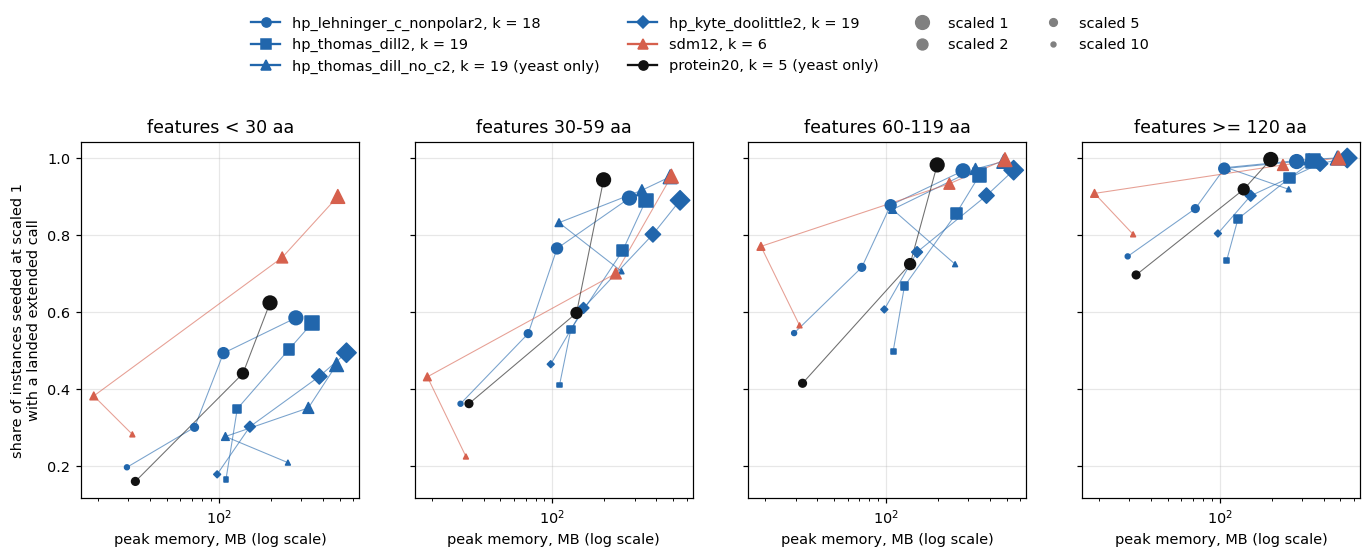

In [14]:
# Figure 4: memory against reach_landed, one point per (arm, scaled, length bin).
# A task shorter than Nextflow's first memory sample reports the shell wrapper's 1.6 MB.
# Those points carry no measurement and are left out.
WRAPPER_GB = 0.002
P4 = L1.join(C.select("alphabet", "scaled", "peak_gb", "search_peak_gb"), on=["alphabet", "scaled"])
n_drop = P4.filter(pl.col("search_peak_gb") <= WRAPPER_GB).select("alphabet", "scaled").unique()
print(f"(arm, scaled) left out, search peak_rss at the wrapper's value: {n_drop.height}")
print(n_drop.sort("alphabet", "scaled"))
P4 = P4.filter(pl.col("search_peak_gb") > WRAPPER_GB)
SIZE = {1: 80, 2: 50, 5: 25, 10: 10}
fig, axes = plt.subplots(1, 4, figsize=(15, 4.2), sharey=True)
for ax, b in zip(axes, u.LENGTH_BINS):
    for a in u.ARM_ORDER:
        t = P4.filter((pl.col("alphabet") == a) & (pl.col("length_bin") == b)).sort("scaled")
        if t.height == 0:
            continue
        c = GROUP_COLOR[group(a)]
        ax.plot(t["peak_gb"] * 1024, t["landed"], color=c, lw=0.7, alpha=0.6)
        ax.scatter(t["peak_gb"] * 1024, t["landed"], color=c, marker=MARK[a],
                   s=[SIZE[x] for x in t["scaled"]], zorder=3)
    ax.set_xscale("log"); ax.set_title(f"features {b} aa"); ax.set_xlabel("peak memory, MB (log scale)"); ax.grid(alpha=0.3)
axes[0].set_ylabel("share of instances seeded at scaled 1\nwith a landed extended call")
extra = [Line2D([], [], ls="none", marker="o", color="grey", markersize=np.sqrt(SIZE[x]), label=f"scaled {x}")
         for x in u.SCALED]
fig.legend(handles=arm_handles(extra, arms=EXT_ARMS, species_note=SPN), loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=4, frameon=False)
fig.savefig(FIG / "270_memory_vs_reach_landed.png")
print(P4.select("alphabet", "scaled", "length_bin", "peak_gb", "landed").sort("alphabet", "length_bin", "scaled"))

Figure 4 shows only the points with a real memory reading. Read it as a placeholder: the
x axis spans 0.02 to 0.54 GB on targets of 172 and 298 proteins.

Rows with a finite region_evalue (an infinite one means no E-value fit for that index):
shape: (64, 5)
┌──────────────────────────┬────────┬────────┬─────────────────┬────────┐
│ alphabet                 ┆ scaled ┆ n_rows ┆ n_finite_evalue ┆ run    │
│ ---                      ┆ ---    ┆ ---    ┆ ---             ┆ ---    │
│ str                      ┆ i64    ┆ u32    ┆ u32             ┆ str    │
╞══════════════════════════╪════════╪════════╪═════════════════╪════════╡
│ gbmr4                    ┆ 1      ┆ 49858  ┆ 0               ┆ decoy  │
│ gbmr4                    ┆ 2      ┆ 32133  ┆ 0               ┆ decoy  │
│ gbmr4                    ┆ 5      ┆ 14247  ┆ 0               ┆ decoy  │
│ gbmr4                    ┆ 10     ┆ 7999   ┆ 0               ┆ decoy  │
│ hp_kyte_doolittle2       ┆ 1      ┆ 529050 ┆ 468412          ┆ decoy  │
│ hp_kyte_doolittle2       ┆ 2      ┆ 359576 ┆ 318328          ┆ decoy  │
│ hp_kyte_doolittle2       ┆ 5      ┆ 195202 ┆ 170386          ┆ decoy  │
│ hp_kyte

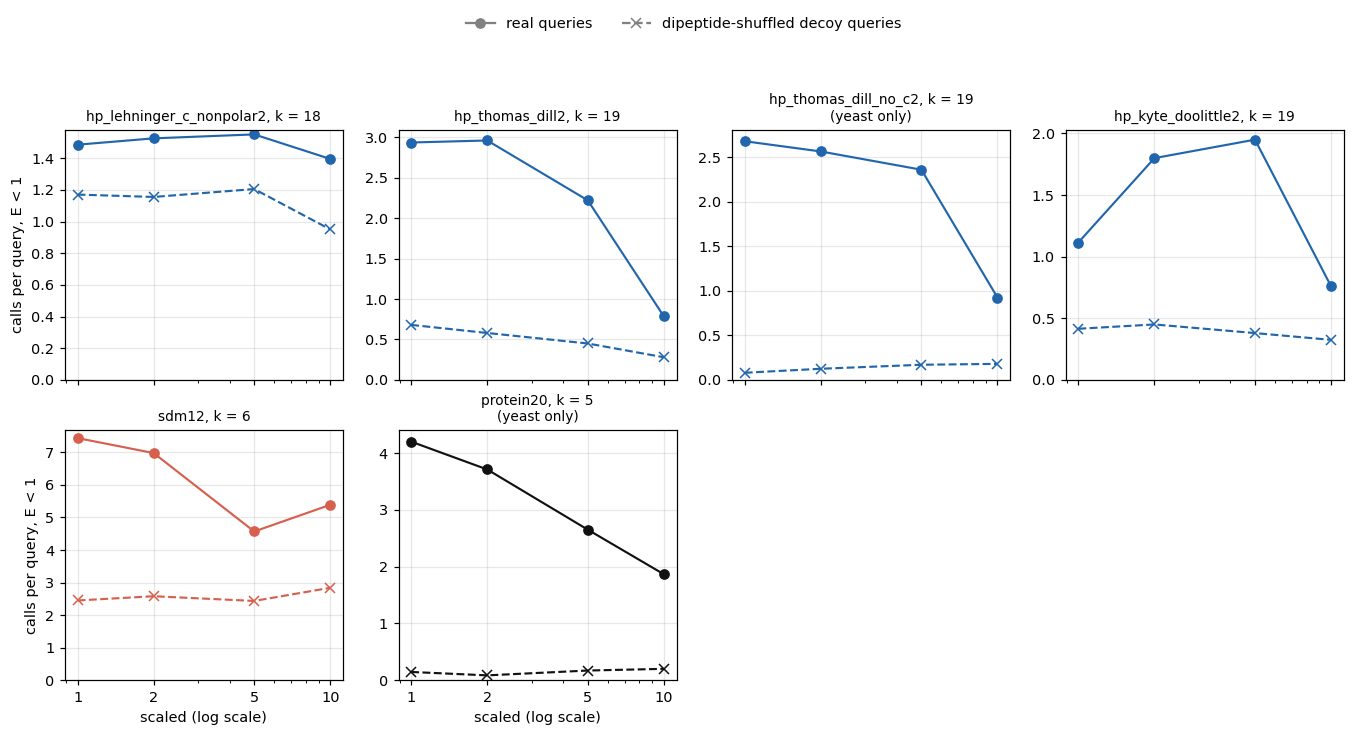

In [15]:
# Figure 5: calls per query at region_evalue < 1, real queries and decoys.
def per_query(d, run):
    d = d.join(EXT_OK, on=["alphabet", "species"], how="semi")
    return (d.filter(pl.col("region_evalue") < 1).group_by(["alphabet", "scaled"])
            .agg(n_calls=pl.len()).with_columns(per_query=pl.col("n_calls") / u.N_QUERIES, run=pl.lit(run)))
grid = pl.DataFrame([(a, s) for a in EXT_ARMS for s in u.SCALED], schema=["alphabet", "scaled"], orient="row")
D = pl.concat([
    grid.join(per_query(reg[r], r), on=["alphabet", "scaled"], how="left")
        .with_columns(run=pl.lit(r), n_calls=pl.col("n_calls").fill_null(0), per_query=pl.col("per_query").fill_null(0.0))
    for r in ("extend", "decoy")])
fin = pl.concat([reg[r].group_by("alphabet", "scaled").agg(
    n_rows=pl.len(), n_finite_evalue=pl.col("region_evalue").is_finite().sum()).with_columns(run=pl.lit(r))
    for r in ("extend", "decoy")]).sort("run", "alphabet", "scaled")
print("Rows with a finite region_evalue (an infinite one means no E-value fit for that index):")
print(fin)
print(D.sort("run", "alphabet", "scaled"))
D.write_csv(TAB / "270_calls_per_query_evalue_lt1.csv")
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5), sharex=True)
for ax in axes.flat[len(EXT_ARMS):]:
    ax.set_visible(False)
for ax, a in zip(axes.flat, EXT_ARMS):
    for r, ls, mk in (("extend", "-", "o"), ("decoy", "--", "x")):
        t = D.filter((pl.col("alphabet") == a) & (pl.col("run") == r)).sort("scaled")
        ax.plot(t["scaled"], t["per_query"], color=GROUP_COLOR[group(a)], ls=ls, marker=mk, lw=1.4)
    ax.set_xscale("log"); ax.set_xticks(u.SCALED, [str(s) for s in u.SCALED])
    ax.set_title(arm_label(a) + (f"\n({SPN[a]})" if a in SPN else ""), fontsize=9); ax.grid(alpha=0.3)
    ax.set_ylim(bottom=0)
for ax in axes[1]:
    ax.set_xlabel("scaled (log scale)")
for ax in axes[:, 0]:
    ax.set_ylabel("calls per query, E < 1")
extra = [Line2D([], [], color="grey", ls="-", marker="o", label="real queries"),
         Line2D([], [], color="grey", ls="--", marker="x", label="dipeptide-shuffled decoy queries")]
fig.legend(handles=extra, loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False)
fig.savefig(FIG / "270_calls_per_query_real_and_decoy.png")

### Figure 5

Decoy calls per query at region_evalue < 1, scaled 1 against 10: hp_kyte_doolittle2 0.42
against 0.33, hp_thomas_dill2 0.68 against 0.28, hp_thomas_dill_no_c2 (yeast) 0.08 against
0.18, protein20 (yeast) 0.15 against 0.20, sdm12 2.45 against 2.84. Real queries over the
same range: hp_thomas_dill2 2.94 against 0.79, protein20 4.20 against 1.87, sdm12 7.44
against 5.39. The decoy rate moves by at most 0.4 calls per query; real calls change by up to
2.3. Each index fits its own K, so the E-value is recalibrated at each scaled; the
decoy count at E < 1 stays near the same level, which is what that fit is for. Counts per
query are over both species where both were extended, yeast only otherwise.

In [16]:
# The answer per arm: largest scaled whose reach_landed in both bins under 60 aa stays within
# 5 percentage points of scaled 1, on instances seeded at scaled 1.
def largest_within(Ltab, label):
    short = Ltab.filter(pl.col("length_bin").is_in(u.SHORT_BINS))
    ref = short.filter(pl.col("scaled") == 1).select("alphabet", "length_bin", ref="landed")
    drop = short.join(ref, on=["alphabet", "length_bin"]).with_columns(drop_pp=(pl.col("ref") - pl.col("landed")) * 100)
    # Largest scaled s such that every scaled up to s stays within 5 points in both bins.
    ok = (drop.group_by("alphabet", "scaled").agg(worst_drop_pp=pl.col("drop_pp").max(), n_bins=pl.len())
          .with_columns(within_5pp=(pl.col("worst_drop_pp") <= 5) & (pl.col("n_bins") == len(u.SHORT_BINS)))
          .sort("alphabet", "scaled"))
    ok = ok.with_columns(all_ok_so_far=pl.col("within_5pp").cum_min().over("alphabet"))
    best = (ok.filter(pl.col("all_ok_so_far") & (pl.col("scaled") > 1)).group_by("alphabet")
            .agg(largest_scaled=pl.col("scaled").max()))
    ans = (pl.DataFrame({"alphabet": EXT_ARMS}).join(best, on="alphabet", how="left")
           .join(C.filter(pl.col("scaled") == 1).select("alphabet", peak1_gb="peak_gb", time1_s="total_s"), on="alphabet")
           .join(C.select("alphabet", "scaled", "peak_gb", "total_s"),
                 left_on=["alphabet", "largest_scaled"], right_on=["alphabet", "scaled"], how="left")
           .with_columns(memory_saved_mb=(pl.col("peak1_gb") - pl.col("peak_gb")) * 1024,
                         time_saved_s=pl.col("time1_s") - pl.col("total_s"), reading=pl.lit(label)))
    print(f"--- {label}: drop in reach_landed from scaled 1, percentage points")
    print(drop.sort("alphabet", "length_bin", "scaled").select("alphabet", "length_bin", "scaled", "n", "landed", "ref", "drop_pp")
          .with_columns(pl.selectors.float().round(3)))
    return ans
ANS = pl.concat([largest_within(L1, "all pairs"), largest_within(L1h, "Pfam-homolog pairs")])
print(ANS.with_columns(pl.selectors.float().round(3)))
ANS.write_csv(TAB / "270_largest_scaled_within_5pp.csv")

--- all pairs: drop in reach_landed from scaled 1, percentage points
shape: (48, 7)
┌──────────────────────────┬────────────┬────────┬──────┬────────┬───────┬─────────┐
│ alphabet                 ┆ length_bin ┆ scaled ┆ n    ┆ landed ┆ ref   ┆ drop_pp │
│ ---                      ┆ ---        ┆ ---    ┆ ---  ┆ ---    ┆ ---   ┆ ---     │
│ str                      ┆ str        ┆ i64    ┆ u32  ┆ f64    ┆ f64   ┆ f64     │
╞══════════════════════════╪════════════╪════════╪══════╪════════╪═══════╪═════════╡
│ hp_kyte_doolittle2       ┆ 30-59      ┆ 1      ┆ 2648 ┆ 0.89   ┆ 0.89  ┆ 0.0     │
│ hp_kyte_doolittle2       ┆ 30-59      ┆ 2      ┆ 2648 ┆ 0.802  ┆ 0.89  ┆ 8.837   │
│ hp_kyte_doolittle2       ┆ 30-59      ┆ 5      ┆ 2648 ┆ 0.611  ┆ 0.89  ┆ 27.946  │
│ hp_kyte_doolittle2       ┆ 30-59      ┆ 10     ┆ 2648 ┆ 0.465  ┆ 0.89  ┆ 42.56   │
│ hp_kyte_doolittle2       ┆ < 30       ┆ 1      ┆ 1317 ┆ 0.494  ┆ 0.494 ┆ 0.0     │
│ hp_kyte_doolittle2       ┆ < 30       ┆ 2      ┆ 1317 ┆ 0.433  ┆

## 8. Largest scaled within 5 points of scaled 1, per arm

The rule: the largest $s$ for which reach_landed (on instances seeded at scaled 1) drops by
at most 5 percentage points in both the under-30 and the 30-59 bins at every scaled up to
$s$. No arm qualifies at $s = 2$, so there is no qualifying value and no saving to report.

Worse of the two short bins at scaled 2, all pairs / Pfam-family pairs, in points:

| arm | all pairs | Pfam-family pairs |
|---|---|---|
| hp_kyte_doolittle2 k19 | 8.8 | 10.7 |
| hp_thomas_dill2 k19 | 13.1 | 8.5 |
| hp_thomas_dill_no_c2 k19 (yeast) | 11.2 | 16.2 |
| hp_lehninger_c_nonpolar2 k18 | 13.1 | 23.5 |
| sdm12 k6 | 25.3 | 16.3 |
| protein20 k5 (yeast) | 34.6 | 38.3 |
| gbmr4 k16, mmseqs12 k7 | not scored: no E-value fit at every scaled | |

Only one short bin of one arm stays within 5 points at scaled 2: hp_thomas_dill_no_c2 on
30-59 residue features, all pairs, 3.5 points.